Computing phase diagram for a = 0.0
Computing phase diagram for a = 0.05
Computing phase diagram for a = 0.1
Computing phase diagram for a = 0.2


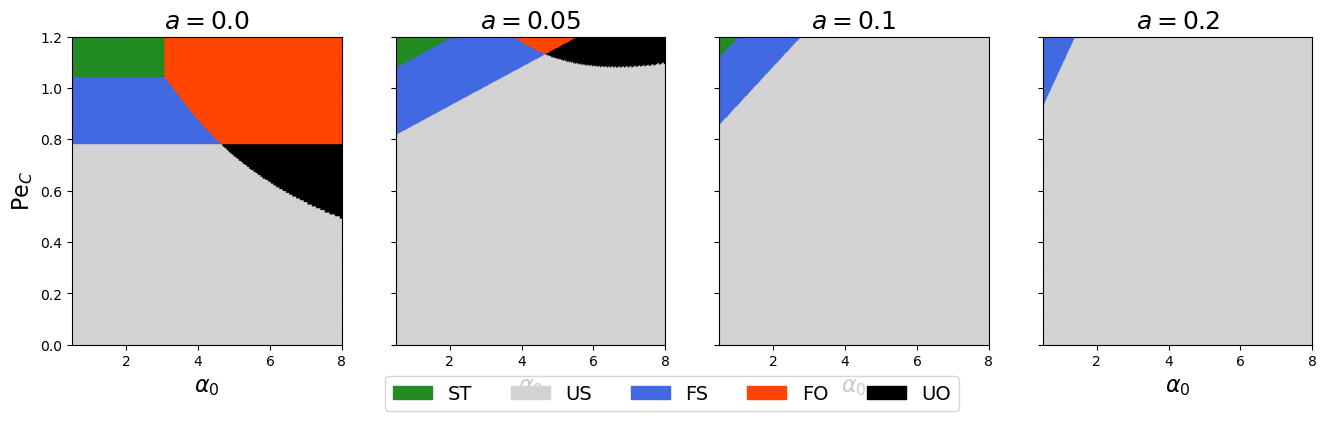

In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import matplotlib.patches as mpatches

# Parameters
phi_m = 0.9
Pe_R  = 1e-3


def dmu_h(phi0: float) -> float:
    φ = phi0
    term1 = 1 / φ
    term2 = -2.0 - 0.6 * φ
    term3 = -(4.0 / np.pi) * Pe_R * phi_m * (-1 / (phi_m - φ) - 1 / phi_m - 1)
    return term1 + term2 + term3



# Dispersion relation (S + aφ)
def omega_plus(q, alpha, Da, PeC_p, a_star):

    M = q**2 * (-1 + q**2)
    D = (q**2 + Da) / alpha

    X = (Da / alpha) * PeC_p * q**2
    X += a_star * q**2

    disc = (M - D)**2 - 4 * X

    return 0.5 * (-(M + D) + np.sqrt(disc.astype(complex)))


# Classifier
def classify(alpha, Da, PeC_p, qvec, a_star):

    ω = omega_plus(qvec, alpha, Da, PeC_p, a_star)

    Re = ω.real
    Im = ω.imag

    if np.all(Re <= 0):
        return "ST"

    small_band = qvec < 0.05
    space = "U" if np.any(Re[small_band] > 0) else "F"

    growth = Re > 0
    time = "O" if np.any(np.abs(Im[growth]) > 1e-6) else "S"

    return space + time


# Phase diagram computation
def compute_phase(phi0, alpha0_vals, PeC_vals, Da0, a_coeff):

    dmu = dmu_h(phi0)

    Da = -Da0 * phi0 / dmu
    a_star = a_coeff * phi0 / dmu

    qvec = np.linspace(0, 2.0, 1000)

    phase = np.empty((len(PeC_vals), len(alpha0_vals)), dtype="<U2")

    for i, PeC in enumerate(PeC_vals):

        PeC_p = -PeC / (phi0**2 * dmu)

        for j, a0 in enumerate(alpha0_vals):

            alpha = -a0 * phi0 * dmu

            phase[i, j] = classify(alpha, Da, PeC_p, qvec, a_star)

    return phase


# plotting routine
if __name__ == "__main__":

    phi0 = 0.8
    Da0  = 0.5

    alpha0_vals = np.linspace(0.5, 8, 500)
    PeC_vals    = np.linspace(0.0, 1.2, 500)

    a_list = [0.0, 0.05, 0.1, 0.2]

    cmap_dict = {"ST": "forestgreen","US": "lightgrey",
                 "FS": "royalblue","FO": "orangered",
                 "UO": "black"}

    fig, axes = plt.subplots(1, 4,figsize=(16, 4), sharex=True,sharey=True)

    for idx, a_coeff in enumerate(a_list):

        print(f"Computing phase diagram for a = {a_coeff}")

        phase = compute_phase(phi0, alpha0_vals, PeC_vals, Da0, a_coeff)

        img = np.zeros((*phase.shape, 3))

        for label, color in cmap_dict.items():
            img[phase == label] = mcolors.to_rgb(color)

        ax = axes[idx]

        ax.imshow(
            img,
            origin="lower",
            extent=[alpha0_vals.min(), alpha0_vals.max(), PeC_vals.min(),PeC_vals.max()
            ],
            aspect="auto")

        ax.set_title(rf"$a = {a_coeff}$", fontsize=18)
        ax.set_xlabel(r"$\alpha_0$",fontsize=16)

        if idx == 0:
            ax.set_ylabel(r"$\mathrm{Pe}_C$",fontsize=16)

    # legend
    patches = [
        mpatches.Patch(color=c, label=l)
        for l, c in cmap_dict.items()]

    fig.legend(handles=patches, loc="lower center", ncol=5,
        bbox_to_anchor=(0.5, -0.08), fontsize=14 )

    plt.show()